In [1]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Data Loading

In [2]:
data = []
labels = []
file_name = []
target_classes = ['healthy', 'Anthracnose', 'bird eye spot']
dataset_path = "Dataset/"

for sub_folder in os.listdir(dataset_path):
    if sub_folder not in target_classes:
        continue
    sub_folder_files = os.listdir(os.path.join(dataset_path, sub_folder))
    count = 0
    for i, filename in enumerate(sub_folder_files):
        if count == 100:
            break
        count += 1
        img_path = os.path.join(dataset_path, sub_folder, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = img.astype(np.uint8)
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
        
data = np.array(data, dtype=object)
labels = np.array(labels)
print("Total data loaded:", len(data))

Total data loaded: 222


## Data Understanding / Data Distribution

C:\Users\jocel\AppData\Local\Temp\ipykernel_16148\1284251213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_labels, y=counts, palette='viridis')


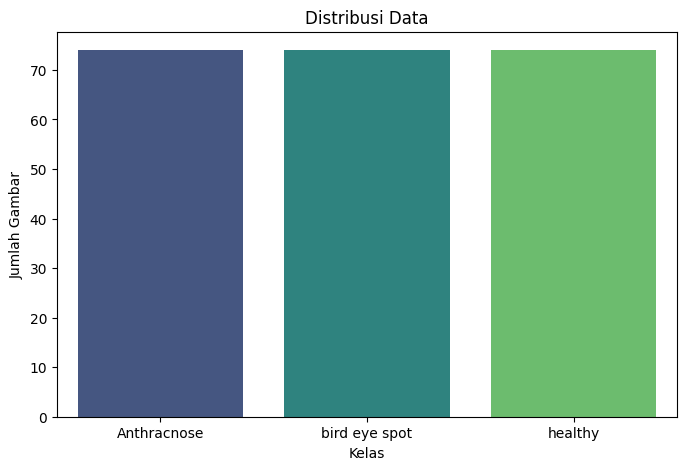

In [3]:
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
sns.barplot(x=unique_labels, y=counts, palette='viridis')
plt.title("Distribusi Data")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()

## Data Augmentation
### Define Augmentation Function

In [4]:
# melakukan augmentasi data (Hanya jika data kurang dari 70-100 per kelas)
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
    pass

In [5]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  222
Data setelah augmentasi:  0


## Data Preparation
### Define Preprocessing Function

In [6]:
def resize(image, target_size=(150, 150)):
    target_width, target_height = target_size
    resized_image = cv.resize(image, (target_width, target_height))
    return resized_image

def prepro(img):
    kernel = np.ones((5,5), np.uint8)
    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    _, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel)
    closing = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)
    return closing

### Preprocessing

In [7]:
dataPreprocessed = []
for i in tqdm(range(len(data))):
    # Resize -> Grayscale -> Threshold -> Opening -> Closing
    img = resize(data[i])
    processed = prepro(img)
    dataPreprocessed.append(processed)

100%|██████████| 222/222 [00:00<00:00, 2128.81it/s]


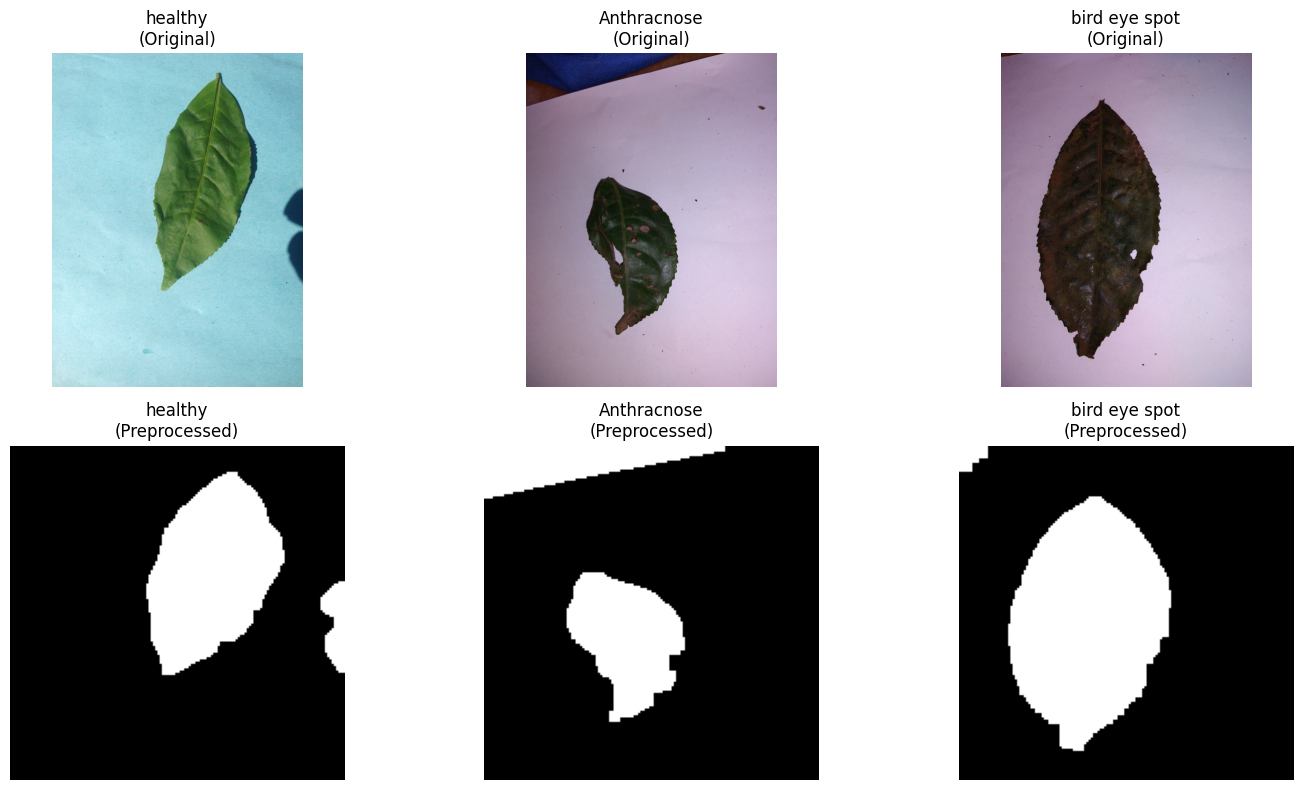

In [8]:
# Label yang ingin ditampilkan
target_labels = ['healthy', 'Anthracnose', 'bird eye spot']

# Siapkan subplots: 2 baris, 3 kolom
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_idx, target in enumerate(target_labels):
    # Cari indeks pertama di mana label cocok dengan target
    found_idx = None
    for i, label in enumerate(labels):
        if label == target:
            found_idx = i
            break # Berhenti setelah menemukan gambar pertama
    
    if found_idx is not None:
        # Baris Atas (indeks 0): Gambar Original
        axes[0, col_idx].imshow(data[found_idx], cmap='gray')
        axes[0, col_idx].set_title(f"{target}\n(Original)")
        axes[0, col_idx].axis('off')
        
        # Baris Bawah (indeks 1): Gambar Setelah Preprocessing
        axes[1, col_idx].imshow(dataPreprocessed[found_idx], cmap='gray')
        axes[1, col_idx].set_title(f"{target}\n(Preprocessed)")
        axes[1, col_idx].axis('off')
    else:
        # Jika label tidak ditemukan, matikan axis
        axes[0, col_idx].axis('off')
        axes[1, col_idx].axis('off')
        print(f"Label '{target}' tidak ditemukan dalam data.")

plt.tight_layout()
plt.show()

### Feature Extraction (GLCM & Wavelet)

In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

In [10]:
def correlation(matriks): return graycoprops(matriks, 'correlation')[0, 0]
def dissimilarity(matriks): return graycoprops(matriks, 'dissimilarity')[0, 0]
def homogenity(matriks): return graycoprops(matriks, 'homogeneity')[0, 0]
def contrast(matriks): return graycoprops(matriks, 'contrast')[0, 0]
def ASM(matriks): return graycoprops(matriks, 'ASM')[0, 0]
def energy(matriks): return graycoprops(matriks, 'energy')[0, 0]
def entropyGlcm(matriks): return entropy(matriks.ravel())

In [11]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []
for i in tqdm(range(len(dataPreprocessed)), desc="GLCM Matrices"):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

GLCM Matrices: 100%|██████████| 222/222 [00:00<00:00, 479.99it/s]


In [12]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [13]:
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

### Wavelet Transform Features

In [14]:
wavelet_features = []
for img in tqdm(dataPreprocessed, desc="Wavelet Extraction"):
    coeffs2 = pywt.dwt2(img, 'haar')
    LL, (LH, HL, HH) = coeffs2
    features = {}
    for name, band in zip(['LL', 'LH', 'HL', 'HH'], [LL, LH, HL, HH]):
        features[f'Wavelet_{name}_mean'] = np.mean(band)
        features[f'Wavelet_{name}_std'] = np.std(band)
        features[f'Wavelet_{name}_energy'] = np.sum(band ** 2)
        hist, _ = np.histogram(band, bins=256, density=True)
        hist = hist[hist > 0]
        features[f'Wavelet_{name}_entropy'] = -np.sum(hist * np.log2(hist))
    wavelet_features.append(features)

df_wavelet = pd.DataFrame(wavelet_features)

Wavelet Extraction: 100%|██████████| 222/222 [00:00<00:00, 699.70it/s]


### Write the extraction's results to CSV 

In [15]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df_glcm = pd.DataFrame(dataTable)
hasilEkstrak = pd.concat([df_glcm, df_wavelet], axis=1)

hasilEkstrak.to_csv('hasil_ekstraksi_p4.csv', index=False)
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Wavelet_LH_energy,Wavelet_LH_entropy,Wavelet_HL_mean,Wavelet_HL_std,Wavelet_HL_energy,Wavelet_HL_entropy,Wavelet_HH_mean,Wavelet_HH_std,Wavelet_HH_energy,Wavelet_HH_entropy
0,IMG_20220503_143242.jpg,Anthracnose,459.684564,893.321247,651.704698,866.960948,0.992931,0.986262,0.989978,0.986667,...,3056175.00,0.564580,0.272000,16.997824,1625625.00,0.547830,0.090667,10.751362,650250.00,0.062623
1,IMG_20220503_143328.jpg,Anthracnose,450.956376,720.514842,538.238255,764.448673,0.993065,0.988920,0.991723,0.988244,...,2698537.50,0.563470,-0.317333,17.826926,1788187.50,0.553021,0.136000,11.529159,747787.50,0.071164
2,IMG_20220503_143336.jpg,Anthracnose,660.432886,817.169272,433.500000,843.529571,0.989844,0.987433,0.993333,0.987028,...,1804443.75,0.551807,0.521333,21.158408,2519718.75,0.560393,-0.113333,11.147069,699018.75,0.066922
3,IMG_20220503_143344.jpg,Anthracnose,541.147651,770.306518,436.409396,714.656997,0.991678,0.988154,0.993289,0.989010,...,1836956.25,0.554650,0.204000,21.569617,2617256.25,0.564646,-0.294667,11.896351,796556.25,0.075032
4,IMG_20220503_143352.jpg,Anthracnose,561.513423,1010.478132,648.795302,919.681546,0.991365,0.984460,0.990023,0.985857,...,2698537.50,0.558957,0.000000,21.368669,2568487.50,0.558233,-0.136000,10.478621,617737.50,0.059639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,UNADJUSTEDNONRAW_thumb_24b.jpg,healthy,657.523490,761.519751,279.302013,656.078555,0.989888,0.988289,0.995705,0.989911,...,861581.25,0.535707,0.204000,20.750142,2422181.25,0.555845,0.068000,10.340473,601481.25,0.058263
218,UNADJUSTEDNONRAW_thumb_24c.jpg,healthy,709.892617,852.316337,340.399329,688.296698,0.989083,0.986893,0.994765,0.989415,...,1072912.50,0.541175,0.181333,24.868195,3478837.50,0.570976,-0.045333,11.017166,682762.50,0.065550
219,UNADJUSTEDNONRAW_thumb_24d.jpg,healthy,704.073826,846.458493,322.942953,682.438854,0.989172,0.986983,0.995034,0.989505,...,1089168.75,0.543383,0.113333,23.246874,3039918.75,0.568695,-0.430667,11.646653,764043.75,0.071658
220,UNADJUSTEDNONRAW_thumb_24e.jpg,healthy,832.087248,869.889870,381.130872,916.752624,0.987204,0.986622,0.994139,0.985902,...,1202962.50,0.550403,-0.181333,25.555961,3673912.50,0.581133,-0.090667,12.946497,942862.50,0.087821


### Features Selection

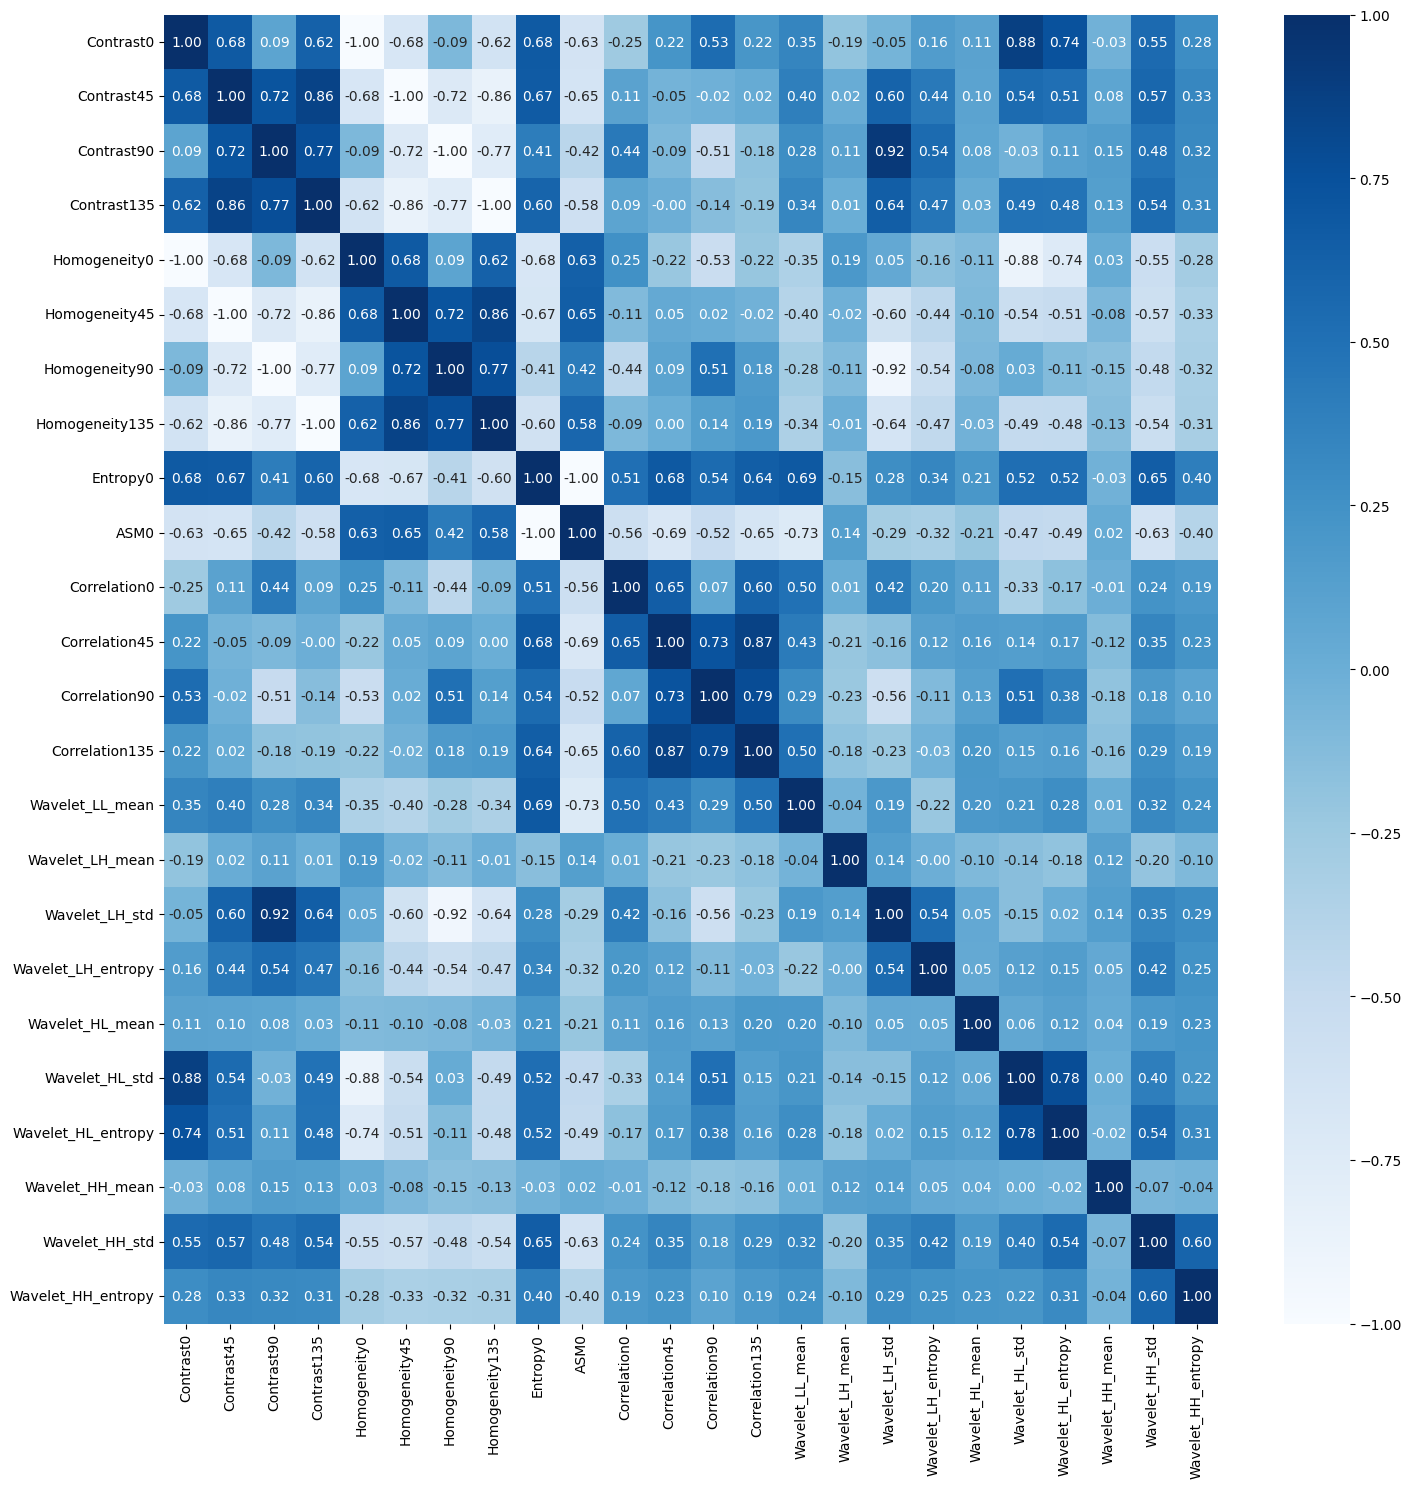

In [16]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()
threshold = 0.95 
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if correlation.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]

y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.show()

## Splitting Data

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(177, 24)
(45, 24)


## Feature Normalization

In [18]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

## Modeling
### Define Model

In [19]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [20]:
rf.fit(X_train, y_train)
print("------Training Set------")
y_pred_rf_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_rf_train)
print("\n------Testing Set------")
y_pred_rf_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf_test)

------Training Set------
               precision    recall  f1-score   support

  Anthracnose       1.00      1.00      1.00        61
bird eye spot       1.00      1.00      1.00        54
      healthy       1.00      1.00      1.00        62

     accuracy                           1.00       177
    macro avg       1.00      1.00      1.00       177
 weighted avg       1.00      1.00      1.00       177

[[61  0  0]
 [ 0 54  0]
 [ 0  0 62]]
Accuracy: 1.0

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.42      0.77      0.54        13
bird eye spot       0.78      0.35      0.48        20
      healthy       0.67      0.67      0.67        12

     accuracy                           0.56        45
    macro avg       0.62      0.60      0.56        45
 weighted avg       0.64      0.56      0.55        45

[[10  2  1]
 [10  7  3]
 [ 4  0  8]]
Accuracy: 0.5555555555555556


### Train SVM Classifier

In [21]:
svm.fit(X_train, y_train)
print("\n------Training Set------")
y_pred_svm_train = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_svm_train)
print("\n------Testing Set------")
y_pred_svm_test = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm_test)


------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.79      0.89      0.84        61
bird eye spot       0.89      0.72      0.80        54
      healthy       0.92      0.97      0.94        62

     accuracy                           0.86       177
    macro avg       0.87      0.86      0.86       177
 weighted avg       0.87      0.86      0.86       177

[[54  5  2]
 [12 39  3]
 [ 2  0 60]]
Accuracy: 0.864406779661017

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.47      0.54      0.50        13
bird eye spot       0.71      0.60      0.65        20
      healthy       0.77      0.83      0.80        12

     accuracy                           0.64        45
    macro avg       0.65      0.66      0.65        45
 weighted avg       0.65      0.64      0.65        45

[[ 7  5  1]
 [ 6 12  2]
 [ 2  0 10]]
Accuracy: 0.6444444444444445


### Train KNN Classifier

In [22]:
knn.fit(X_train, y_train)
print("\n------Training Set------")
y_pred_knn_train = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_knn_train)
print("\n------Testing Set------")
y_pred_knn_test = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn_test)


------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.66      0.75      0.70        61
bird eye spot       0.71      0.65      0.68        54
      healthy       0.97      0.90      0.93        62

     accuracy                           0.77       177
    macro avg       0.78      0.77      0.77       177
 weighted avg       0.78      0.77      0.78       177

[[46 13  2]
 [19 35  0]
 [ 5  1 56]]
Accuracy: 0.7740112994350282

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.42      0.62      0.50        13
bird eye spot       0.73      0.55      0.63        20
      healthy       0.73      0.67      0.70        12

     accuracy                           0.60        45
    macro avg       0.63      0.61      0.61        45
 weighted avg       0.64      0.60      0.61        45

[[ 8  4  1]
 [ 7 11  2]
 [ 4  0  8]]
Accuracy: 0.6


## Evaluation With Confusion Matrix

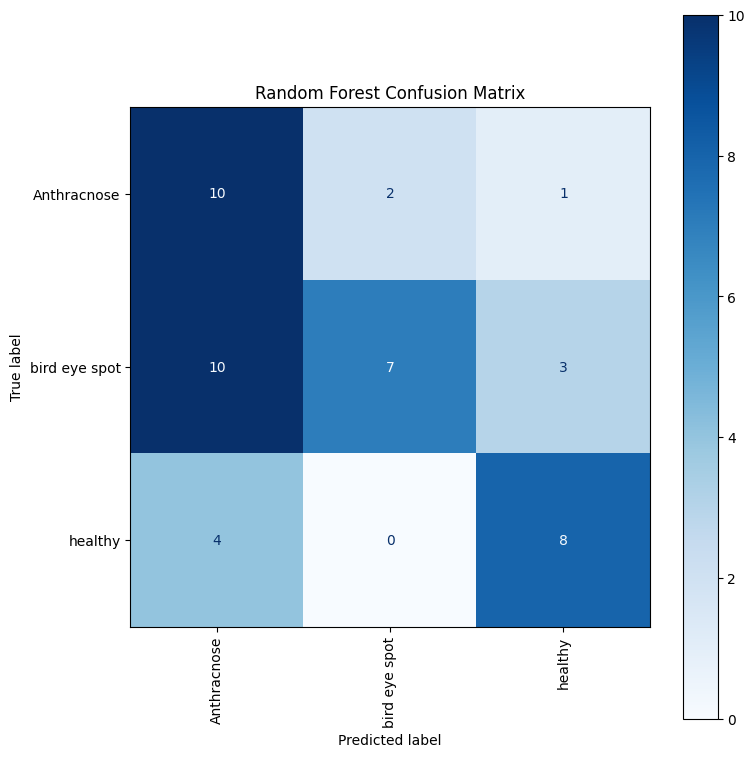

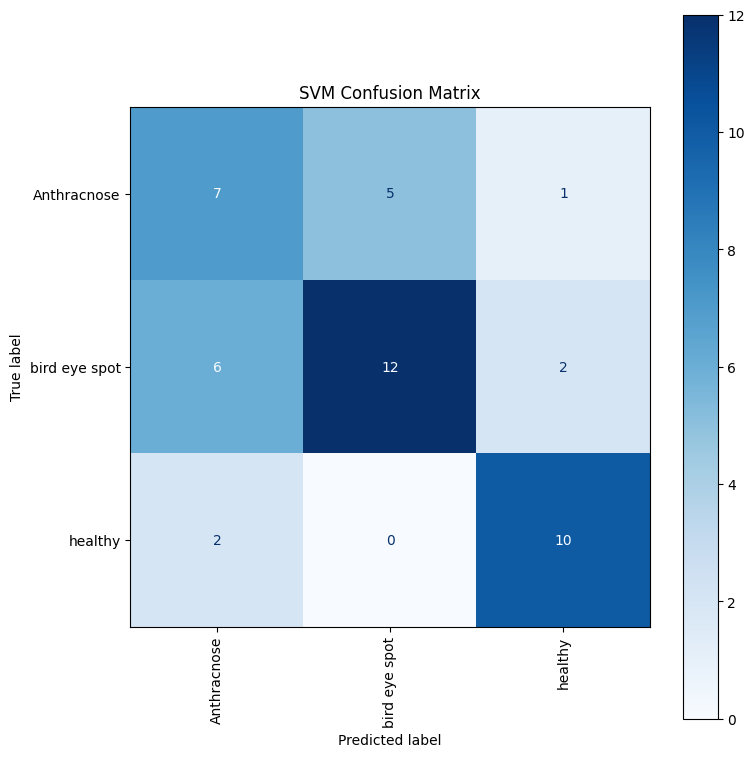

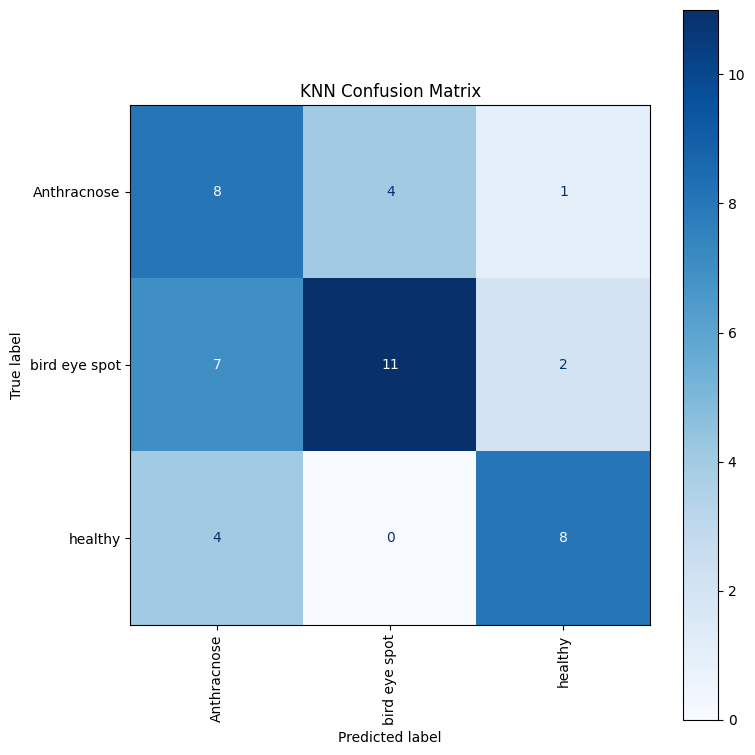

In [23]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8,8))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest Confusion Matrix", "cm_rf_p4.png")
plot_confusion_matrix(y_test, y_pred_svm_test, "SVM Confusion Matrix", "cm_svm_p4.png")
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN Confusion Matrix", "cm_knn_p4.png")